# CreditLens — Exploratory Data Analysis

**Dataset:** UCI Default of Credit Card Clients (id=350)  
**Source:** Yeh & Lien (2009), Expert Systems with Applications  
**Rows:** 30,000 credit card clients in Taiwan, April–September 2005  
**Target:** `default` — did the client miss next month's payment? (1=yes, 0=no)

This notebook covers:
1. Class balance — documenting the imbalance problem
2. Feature distributions — `LIMIT_BAL`, `AGE`, `PAY_*`, `BILL_AMT*`, `PAY_AMT*`
3. Correlation heatmap — identifying the strongest predictors
4. Data quirks — undocumented categories in `EDUCATION` and `MARRIAGE`

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from src.data_loader import load_raw

df = load_raw()
print(f'Shape: {df.shape}')
df.head(3)

Shape: (30000, 24)


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,170000,2,2,2,37,-2,0,0,-1,2,...,96320,48484,33723,562,7348,3799,3498,4773,12351,0
1,50000,2,1,2,36,-2,-1,7,-1,-1,...,26928,-51029,41138,776,630,8947,5291,10397,1956,0
2,250000,2,2,1,34,-1,2,5,-1,5,...,103684,21687,-64188,2774,1316,1407,7268,14009,726,0


## 1. Class Balance

One of the most important facts about this dataset: **defaults are the minority class**.
Predicting 'no default' for every client would yield ~78% accuracy — but catch 0% of actual defaulters.
This is why accuracy is the wrong metric here.

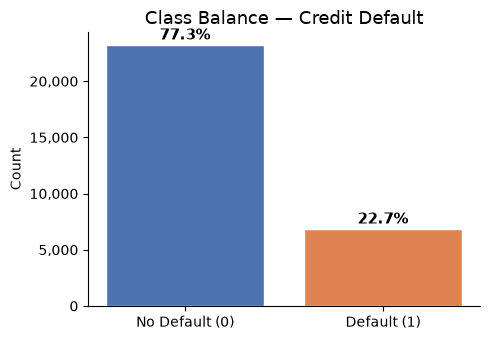

Default rate: 22.71%
Majority-class accuracy baseline: 77.29%


In [2]:
counts = df['default'].value_counts().sort_index()
pcts   = counts / len(df) * 100

fig, ax = plt.subplots(figsize=(5, 3.5))
bars = ax.bar(['No Default (0)', 'Default (1)'], counts.values,
              color=['#4C72B0', '#DD8452'], edgecolor='white')
for bar, pct in zip(bars, pcts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('Class Balance — Credit Default', fontsize=13)
ax.set_ylabel('Count')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('../data/fig_class_balance.png', dpi=120)
plt.show()

print(f"Default rate: {pcts[1]:.2f}%")
print(f"Majority-class accuracy baseline: {pcts[0]:.2f}%")

**Finding:** ~22% of clients defaulted. A naive classifier that always predicts 'no default'
would be ~78% accurate but useless for the bank's actual goal (catching defaulters).
We will use PR-AUC and recall-at-threshold as primary metrics.

## 2. LIMIT_BAL and AGE Distributions

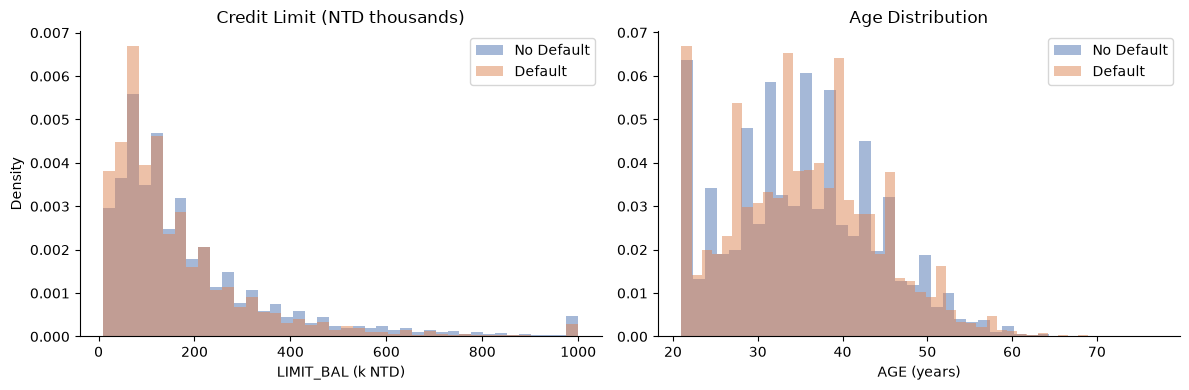

LIMIT_BAL: mean=184834, median=130000, min=10000, max=1000000
AGE: mean=35, median=35, min=21, max=77


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for val, lbl, color in [(0, 'No Default', '#4C72B0'), (1, 'Default', '#DD8452')]:
    subset = df[df['default'] == val]
    axes[0].hist(subset['LIMIT_BAL'] / 1000, bins=40, alpha=0.5,
                 label=lbl, color=color, density=True)
    axes[1].hist(subset['AGE'], bins=40, alpha=0.5,
                 label=lbl, color=color, density=True)

axes[0].set_title('Credit Limit (NTD thousands)', fontsize=12)
axes[0].set_xlabel('LIMIT_BAL (k NTD)')
axes[0].set_ylabel('Density')
axes[0].legend()

axes[1].set_title('Age Distribution', fontsize=12)
axes[1].set_xlabel('AGE (years)')
axes[1].legend()

for ax in axes:
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../data/fig_limit_age.png', dpi=120)
plt.show()

for col in ['LIMIT_BAL', 'AGE']:
    print(f'{col}: mean={df[col].mean():.0f}, median={df[col].median():.0f}, '
          f'min={df[col].min()}, max={df[col].max()}')

## 3. PAY_* Repayment Status Columns

The six `PAY_*` columns encode how many months past due the client was:
- `-2` = no consumption that month  
- `-1` = paid duly  
- `0`  = revolving credit used (minimum payment made)  
- `1–9` = months of delay (1 = 1 month late, ..., 9 = 9+ months late)

`PAY_0` is the most recent month (September 2005); `PAY_6` is the oldest (April 2005).

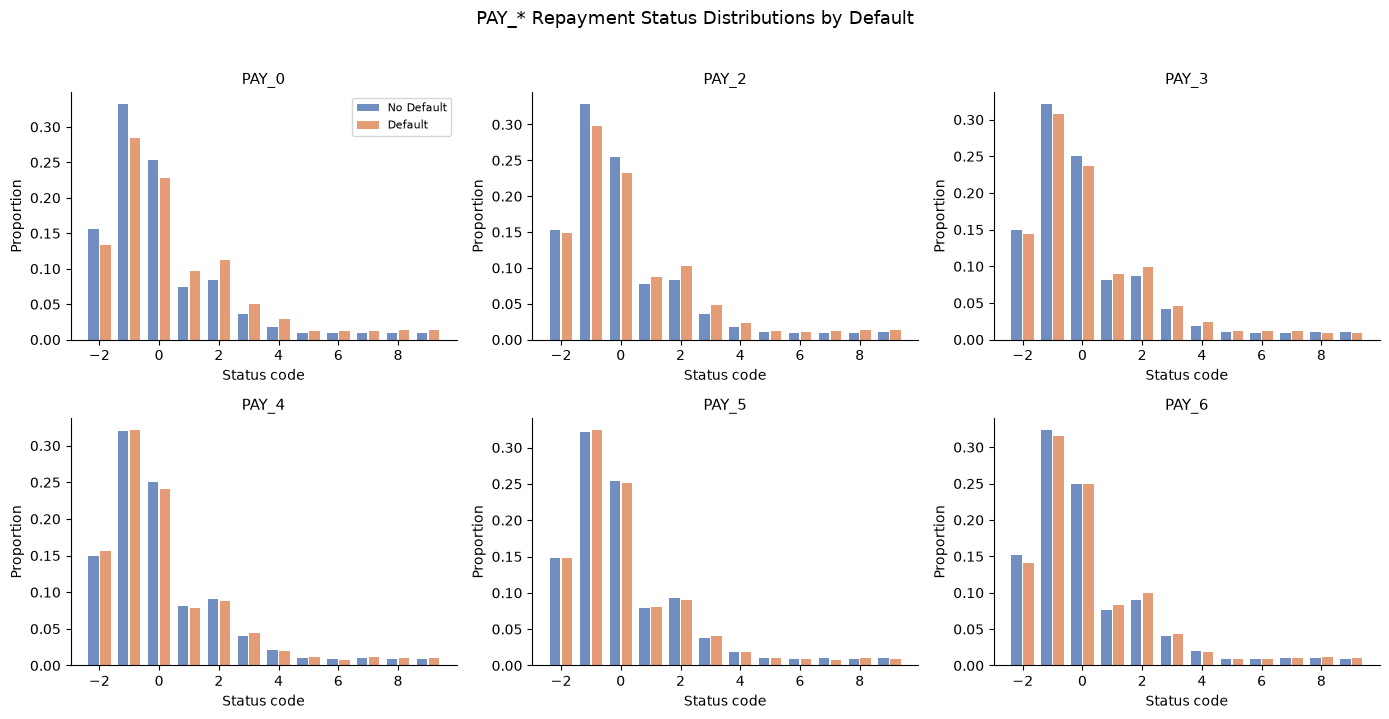

Proportion with ANY late payment (PAY_* > 0) by class:
  No Default: 85.1%
  Default: 88.9%


In [4]:
pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

for i, col in enumerate(pay_cols):
    for val, lbl, color in [(0, 'No Default', '#4C72B0'), (1, 'Default', '#DD8452')]:
        subset = df[df['default'] == val][col]
        vals, cnts = np.unique(subset, return_counts=True)
        axes[i].bar(vals + (0.2 if val == 1 else -0.2), cnts / len(subset),
                    width=0.35, alpha=0.8, color=color, label=lbl)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('Status code')
    axes[i].set_ylabel('Proportion')
    axes[i].spines[['top', 'right']].set_visible(False)
    if i == 0:
        axes[i].legend(fontsize=8)

plt.suptitle('PAY_* Repayment Status Distributions by Default', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../data/fig_pay_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

# Delinquency signal
print('Proportion with ANY late payment (PAY_* > 0) by class:')
for val, lbl in [(0, 'No Default'), (1, 'Default')]:
    subset = df[df['default'] == val]
    any_late = (subset[pay_cols] > 0).any(axis=1).mean()
    print(f'  {lbl}: {any_late:.1%}')

## 4. BILL_AMT and PAY_AMT Distributions

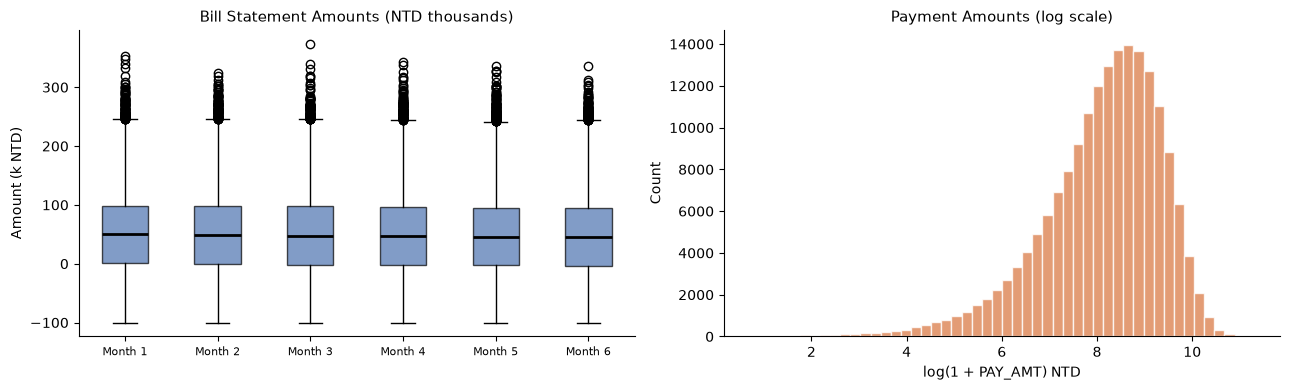

BILL_AMT1 stats (NTD):
count     30000.000000
mean      50120.733833
std       72965.793382
min     -234675.000000
25%        1277.500000
50%       49891.500000
75%       98870.750000
max      352529.000000

Rows with zero BILL_AMT1: 0
Rows with negative BILL_AMT1: 7,338


In [5]:
bill_cols = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
pay_amt_cols = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Box plots: bill amounts over 6 months
bill_data = [df[c].clip(-100_000, 500_000) / 1000 for c in bill_cols]
bp1 = axes[0].boxplot(bill_data, patch_artist=True, widths=0.5,
                       medianprops={'color': 'black', 'linewidth': 2})
for patch in bp1['boxes']:
    patch.set_facecolor('#4C72B0')
    patch.set_alpha(0.7)
axes[0].set_xticklabels([c.replace('BILL_AMT', 'Month ') for c in bill_cols], fontsize=8)
axes[0].set_title('Bill Statement Amounts (NTD thousands)', fontsize=11)
axes[0].set_ylabel('Amount (k NTD)')
axes[0].spines[['top', 'right']].set_visible(False)

# Log-scale histogram of payment amounts
pay_flat = df[pay_amt_cols].values.flatten()
pay_flat = pay_flat[pay_flat > 0]
axes[1].hist(np.log1p(pay_flat), bins=50, color='#DD8452', alpha=0.8, edgecolor='white')
axes[1].set_title('Payment Amounts (log scale)', fontsize=11)
axes[1].set_xlabel('log(1 + PAY_AMT) NTD')
axes[1].set_ylabel('Count')
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../data/fig_bill_pay_amounts.png', dpi=120)
plt.show()

print('BILL_AMT1 stats (NTD):')
print(df['BILL_AMT1'].describe().to_string())
print(f'\nRows with zero BILL_AMT1: {(df["BILL_AMT1"] == 0).sum():,}')
print(f'Rows with negative BILL_AMT1: {(df["BILL_AMT1"] < 0).sum():,}')

## 5. Correlation Heatmap

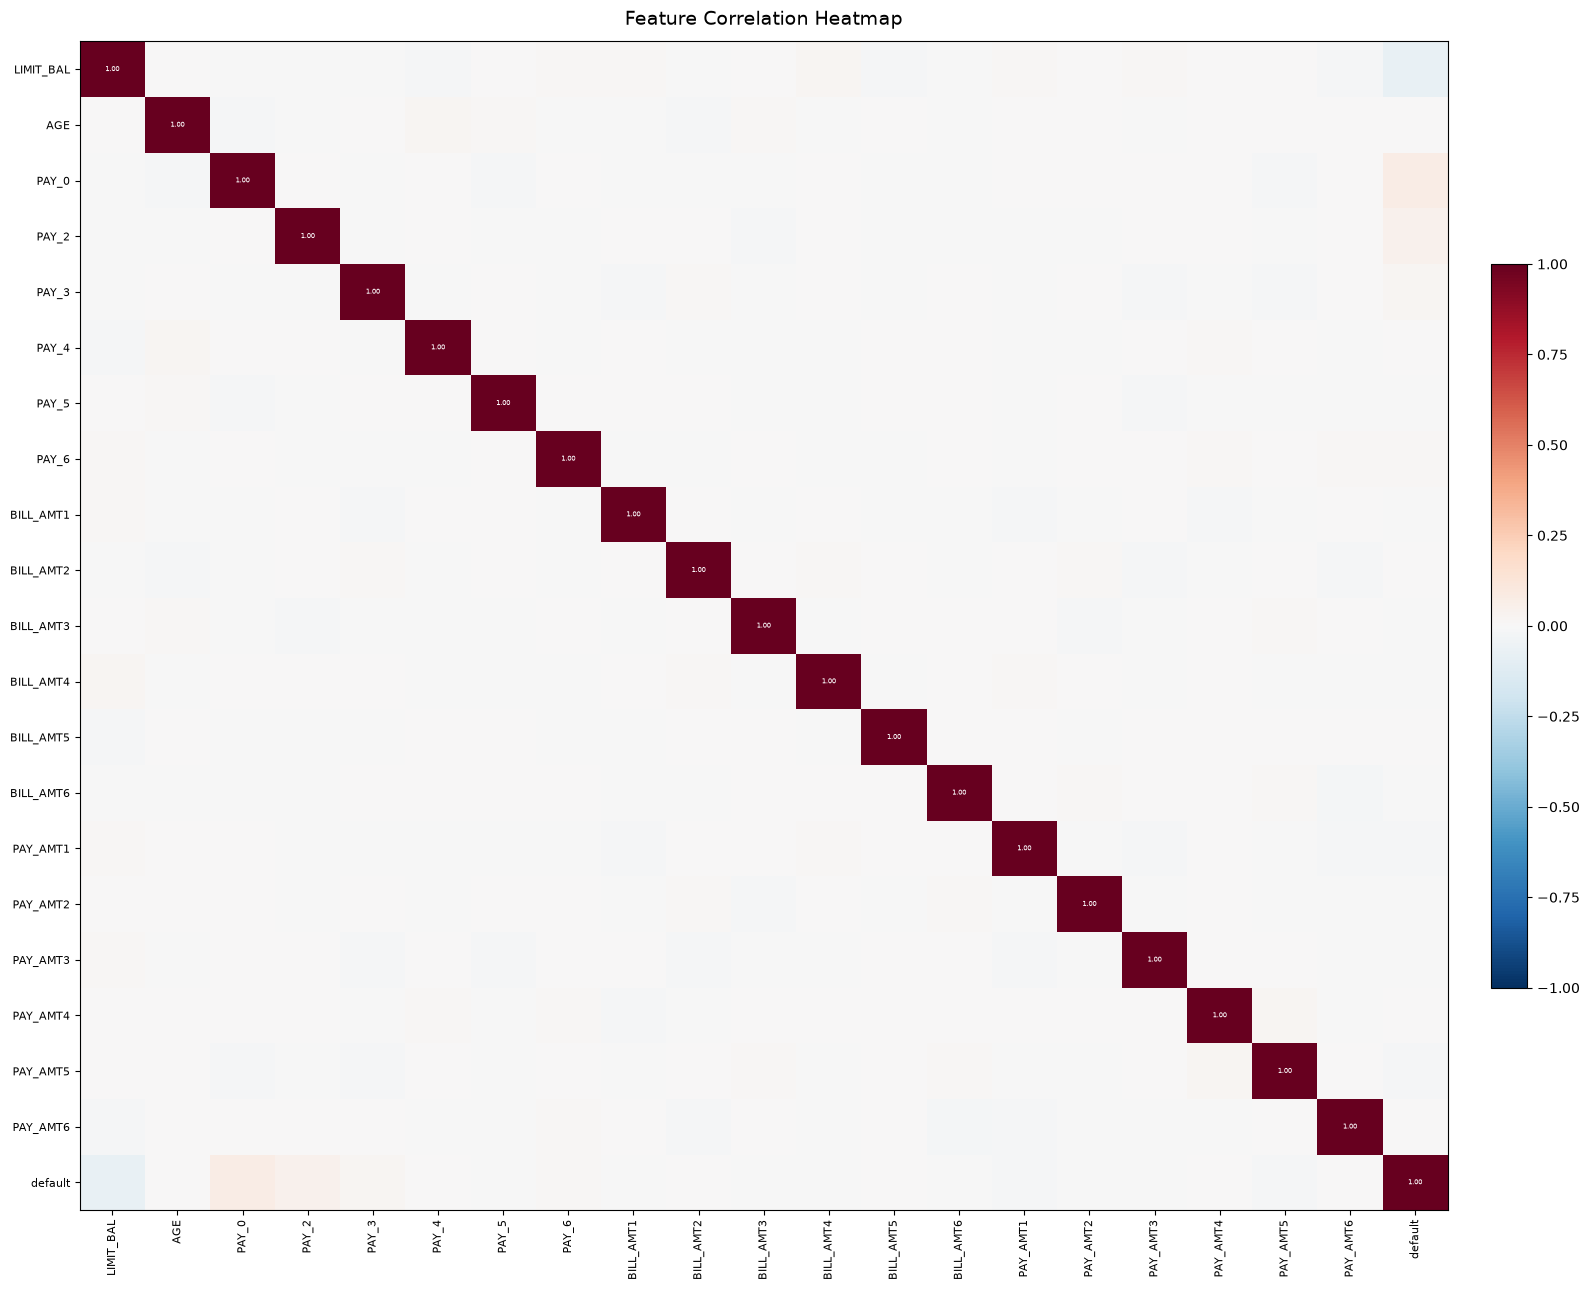

Top 10 features by |correlation| with default:
PAY_0        0.074927
LIMIT_BAL    0.074619
PAY_2        0.045087
PAY_3        0.021753
PAY_AMT1     0.014526
PAY_6        0.012923
PAY_AMT5     0.010998
BILL_AMT5    0.006885
AGE          0.006213
PAY_AMT2     0.005164


In [6]:
numeric_cols = ['LIMIT_BAL', 'AGE'] + pay_cols + bill_cols + pay_amt_cols + ['default']
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(16, 13))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, fraction=0.025, pad=0.03)

ax.set_xticks(range(len(numeric_cols)))
ax.set_yticks(range(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=90, fontsize=8)
ax.set_yticklabels(numeric_cols, fontsize=8)

for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        v = corr.values[i, j]
        if abs(v) > 0.2:
            ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                    fontsize=5, color='white' if abs(v) > 0.5 else 'black')

ax.set_title('Feature Correlation Heatmap', fontsize=14, pad=12)
plt.tight_layout()
plt.savefig('../data/fig_correlation_heatmap.png', dpi=120)
plt.show()

# Show top correlations with target
target_corr = corr['default'].drop('default').abs().sort_values(ascending=False)
print('Top 10 features by |correlation| with default:')
print(target_corr.head(10).to_string())

## 6. Data Quirks — Undocumented Categories

### EDUCATION
The data dictionary defines only 4 categories: 1=graduate school, 2=university, 3=high school, 4=others.  
However, the dataset contains values **0, 5, and 6** which are NOT in the official documentation.  
These are treated as 'other/unknown' and will be collapsed in preprocessing.

### MARRIAGE
Documented values: 1=married, 2=single, 3=others.  
The dataset also contains **0**, which is undocumented — likely a data entry error or 'unknown'.  
Will be collapsed to 'other' in preprocessing.

In [7]:
print('EDUCATION value counts:')
edu_vc = df['EDUCATION'].value_counts().sort_index()
print(edu_vc.to_string())
print(f"\nUndocumented EDUCATION values (0, 5, 6): {df['EDUCATION'].isin([0, 5, 6]).sum()} rows "
      f"({df['EDUCATION'].isin([0, 5, 6]).mean():.2%})")

print('\nMARRIAGE value counts:')
mar_vc = df['MARRIAGE'].value_counts().sort_index()
print(mar_vc.to_string())
print(f"\nUndocumented MARRIAGE value (0): {(df['MARRIAGE'] == 0).sum()} rows "
      f"({(df['MARRIAGE'] == 0).mean():.2%})")

# Default rate by EDUCATION
print('\nDefault rate by EDUCATION:')
print(df.groupby('EDUCATION')['default'].agg(['mean', 'count']).round(3).to_string())

# Default rate by MARRIAGE
print('\nDefault rate by MARRIAGE:')
print(df.groupby('MARRIAGE')['default'].agg(['mean', 'count']).round(3).to_string())

EDUCATION value counts:
EDUCATION
0       30
1    10511
2    14174
3     4875
4      315
5       60
6       35

Undocumented EDUCATION values (0, 5, 6): 125 rows (0.42%)

MARRIAGE value counts:
MARRIAGE
0       89
1    13634
2    15963
3      314

Undocumented MARRIAGE value (0): 89 rows (0.30%)

Default rate by EDUCATION:
            mean  count
EDUCATION              
0          0.267     30
1          0.226  10511
2          0.223  14174
3          0.239   4875
4          0.241    315
5          0.167     60
6          0.200     35

Default rate by MARRIAGE:
           mean  count
MARRIAGE              
0         0.225     89
1         0.226  13634
2         0.228  15963
3         0.245    314


## Summary

| Finding | Implication |
|---------|-------------|
| ~22% default rate (class imbalance) | Use stratified splits; optimize PR-AUC, not accuracy |
| `PAY_*` columns show the strongest correlation with default | Most important feature group — recent delinquency is highly predictive |
| `BILL_AMT` columns are highly correlated with each other | Multicollinearity expected; XGBoost handles this natively |
| `EDUCATION` has undocumented values 0, 5, 6 | Collapse to 'other' (4) in preprocessing |
| `MARRIAGE` has undocumented value 0 | Collapse to 'other' (3) in preprocessing |
| `LIMIT_BAL` is right-skewed | May benefit from log transform in logistic regression |
| `PAY_AMT*` have many zeros | Zero-inflated; use log(1+x) transformation |